# Predicted vs Actual by Category

For each model, predicted vs actual delivery time on the test set, faceted by each observed value of Traffic_Level, Weather, and Vehicle_Type -- to see whether a model is systematically worse for a specific category (e.g. Foggy weather, High traffic).

Run this notebook via `kedro jupyter notebook` (or `kedro jupyter lab`) from the project root so the `catalog` variable is available.

In [7]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [9]:
CATEGORY_COLS = ["Traffic_Level", "Weather", "Vehicle_Type"]

prediction_tables = {
    "Linear Regression": "modout_prediction_linear_regression",
    "Lasso Regression": "modout_prediction_lasso_regression",
    "Random Forest": "modout_prediction_random_forest",
    "XGBoost": "modout_prediction_xgboost",
    "CatBoost": "modout_prediction_catboost",
}

# modin_test_native_categorical (Parquet) keeps its original row index through
# the catalog round-trip, but modout_prediction_* (CSV) does not -- it comes
# back re-indexed 0..n-1. Both still have the same rows in the same order
# (nothing in the pipeline reorders test rows after the initial split), so
# reset_index(drop=True) on both before combining aligns them correctly by
# position rather than by stale index labels.
category_values = catalog.load("modin_test_native_categorical")[CATEGORY_COLS].reset_index(
    drop=True
)

[08/17/26 10:14:02] INFO     Loading data from modin_test_native_categorical                   ]8;id=3408946;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3408947;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (ParquetDataset)...                                                                   

In [10]:
def plot_predictions_by_category(model_name, predictions, category_col):
    category_levels = sorted(predictions[category_col].unique())
    fig, axes = plt.subplots(
        1,
        len(category_levels),
        figsize=(3.5 * len(category_levels), 3.5),
        sharex=True,
        sharey=True,
    )
    if len(category_levels) == 1:
        axes = [axes]

    for ax, level in zip(axes, category_levels):
        subset = predictions[predictions[category_col] == level]
        r2 = r2_score(subset["y_true"], subset["y_pred"])
        ax.scatter(subset["y_true"], subset["y_pred"], alpha=0.5, s=15)

        lims = [
            min(subset["y_true"].min(), subset["y_pred"].min()),
            max(subset["y_true"].max(), subset["y_pred"].max()),
        ]
        ax.plot(lims, lims, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{category_col}={level}\nR²={r2:.2f}")
        ax.set_xlabel("Actual (min)")

    axes[0].set_ylabel("Predicted (min)")
    fig.suptitle(f"{model_name}: Predicted vs Actual by {category_col}")
    fig.tight_layout()
    plt.show()

                    INFO     Loading data from modout_prediction_linear_regression             ]8;id=3408952;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3408953;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (CSVDataset)...                                                                       

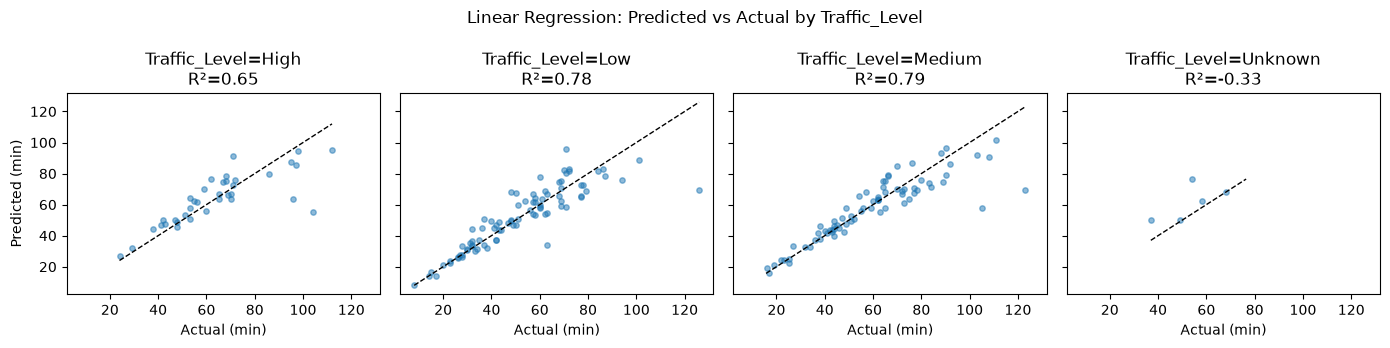

                    WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3408958;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3408959;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

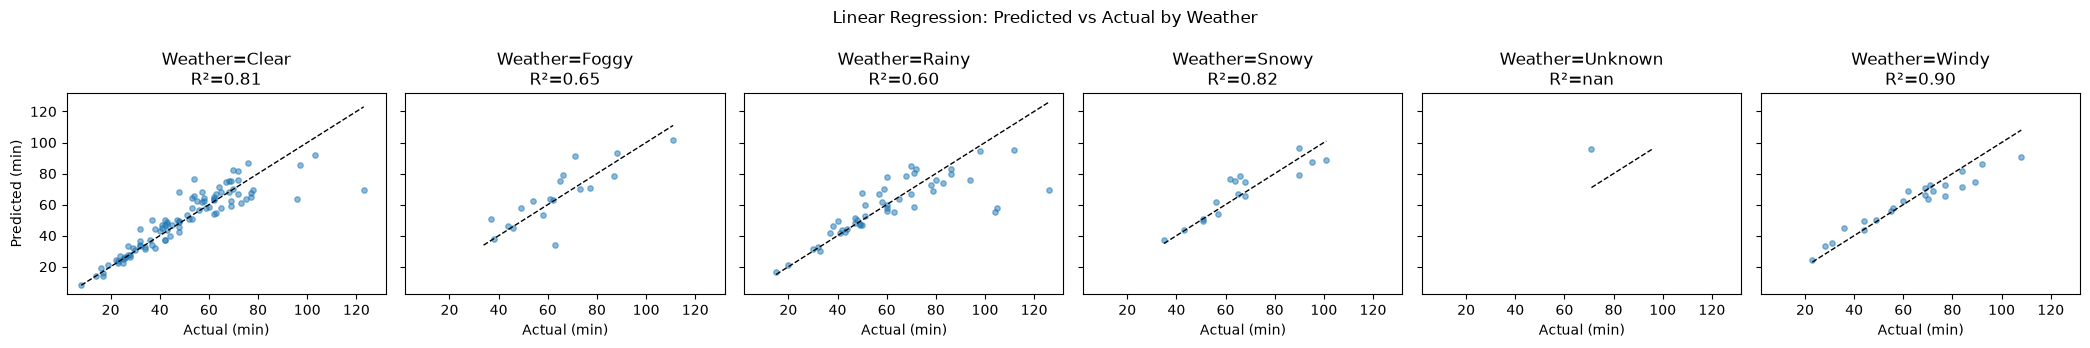

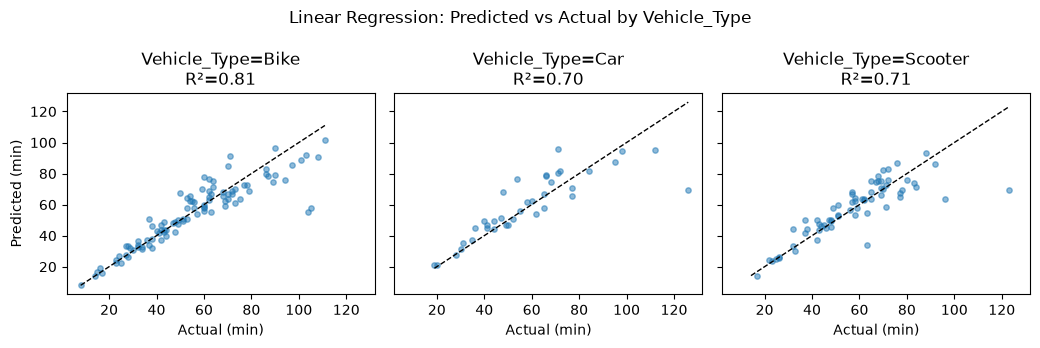

[08/17/26 10:14:03] INFO     Loading data from modout_prediction_lasso_regression              ]8;id=3408964;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3408965;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\
                             (CSVDataset)...                                                                       

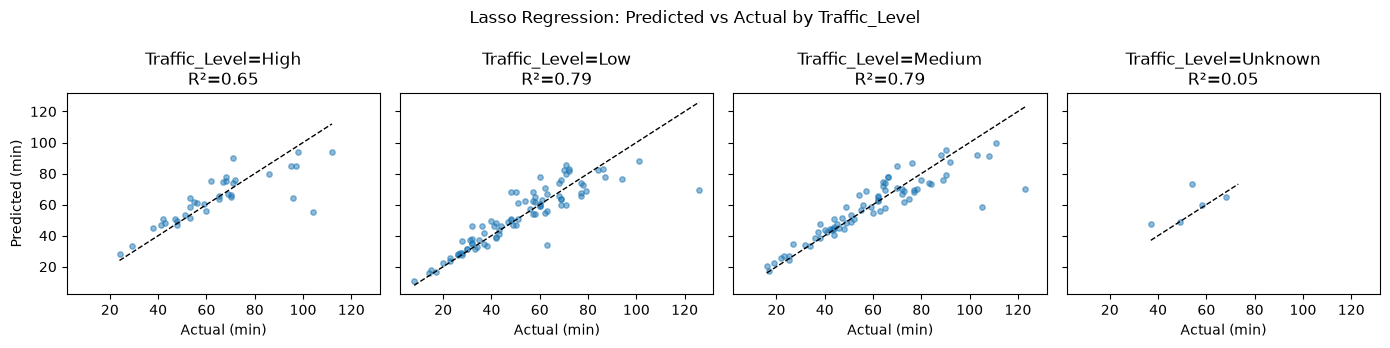

[08/17/26 10:14:04] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3408970;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3408971;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

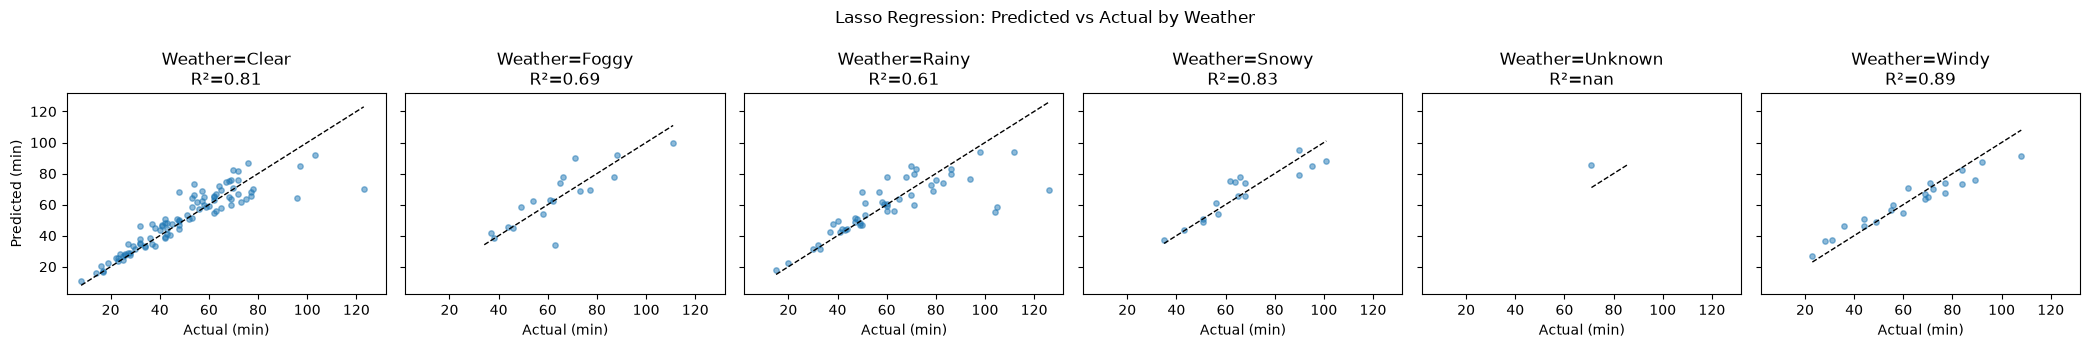

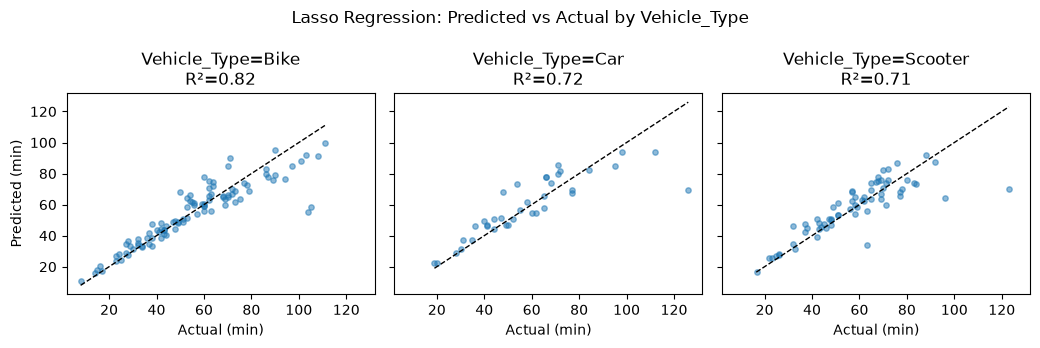

[08/17/26 10:14:05] INFO     Loading data from modout_prediction_random_forest (CSVDataset)... ]8;id=3408976;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3408977;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

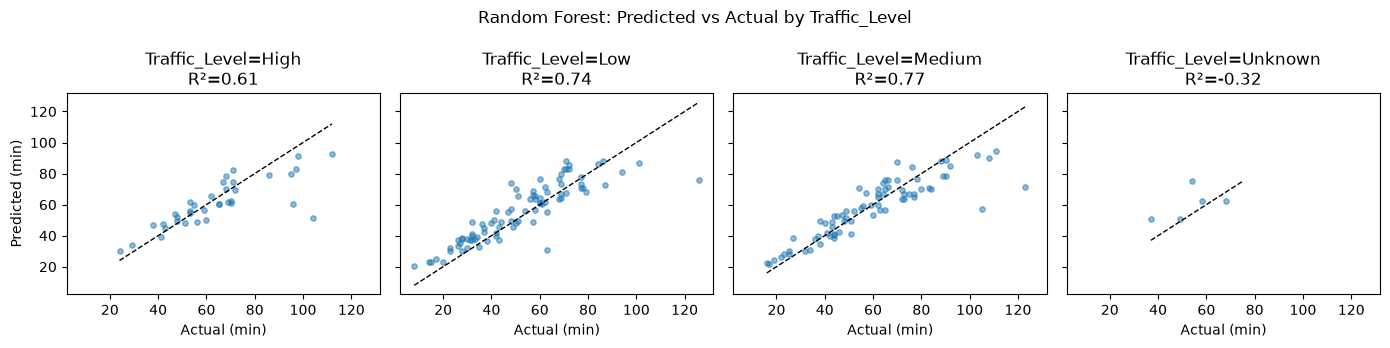

[08/17/26 10:14:06] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3408982;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3408983;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

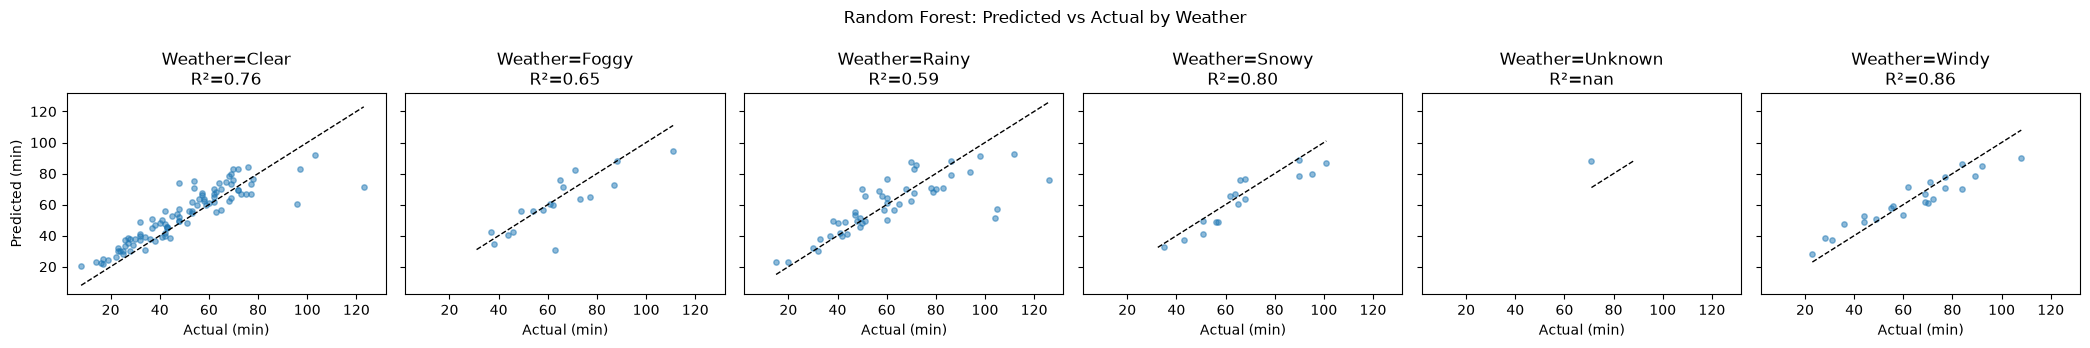

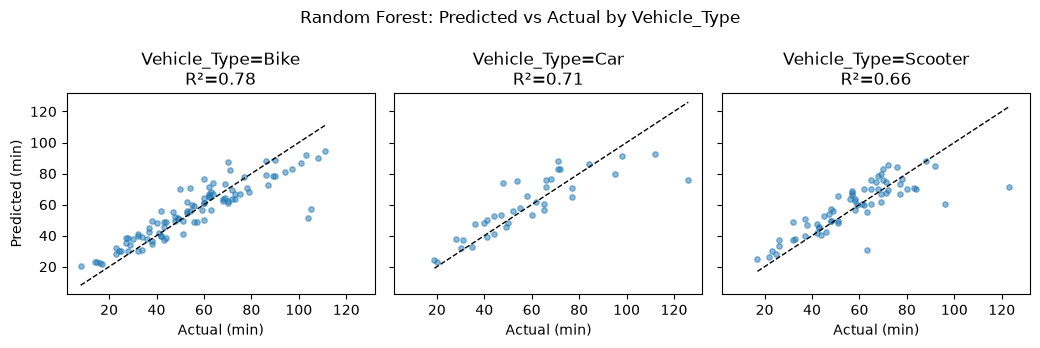

                    INFO     Loading data from modout_prediction_xgboost (CSVDataset)...       ]8;id=3408988;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3408989;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

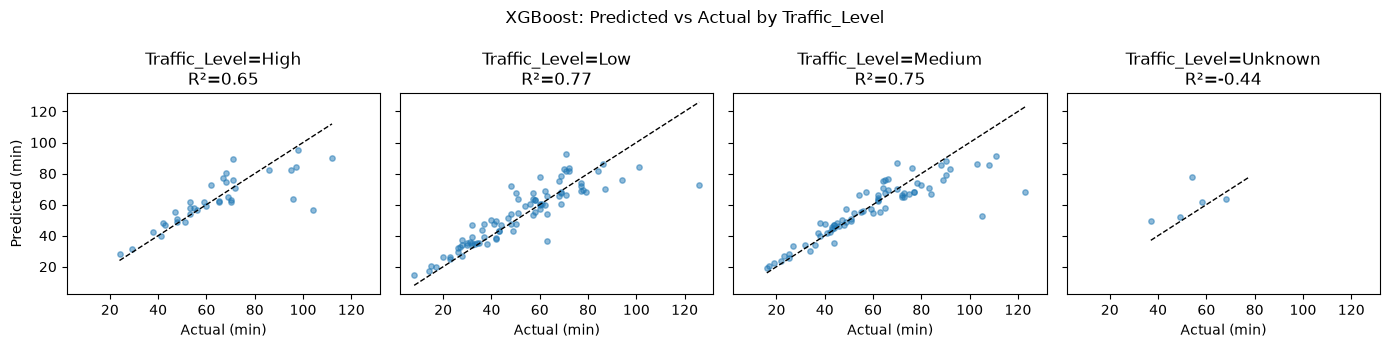

[08/17/26 10:14:07] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3408994;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3408995;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

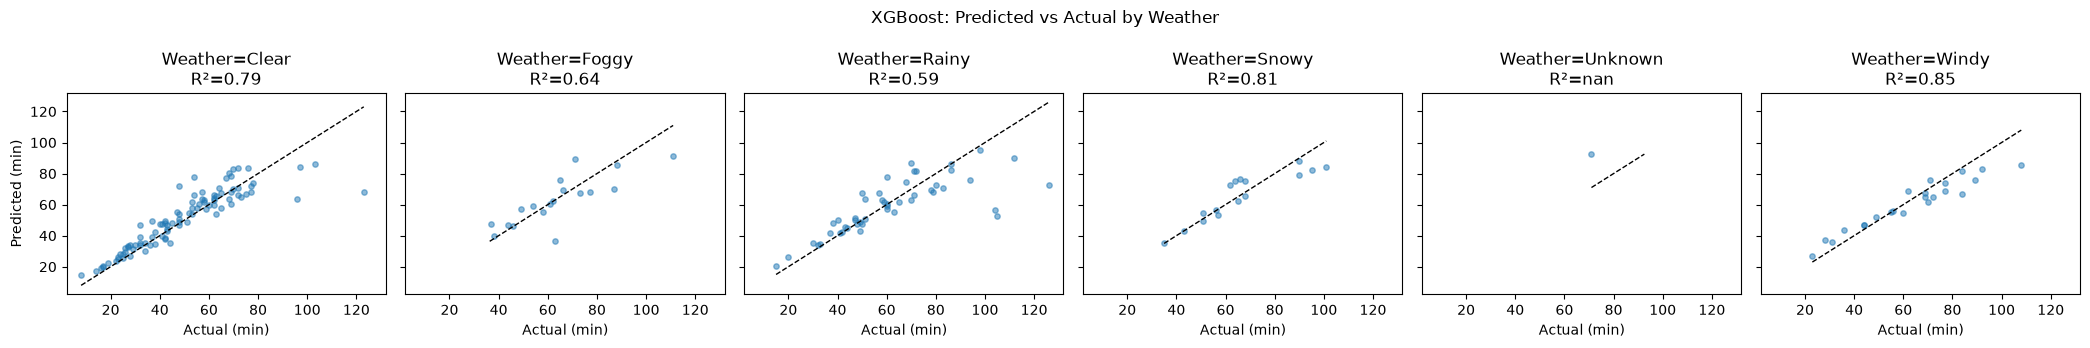

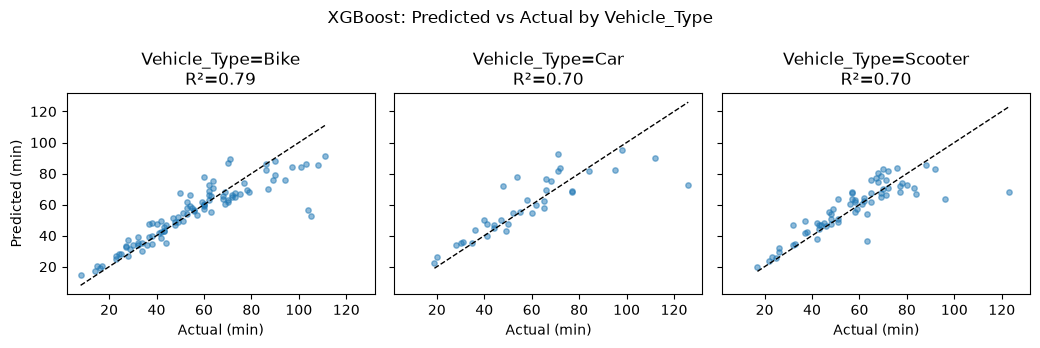

[08/17/26 10:14:08] INFO     Loading data from modout_prediction_catboost (CSVDataset)...      ]8;id=3409000;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=3409001;file:///opt/conda/envs/deliveryenv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1050\1050]8;;\

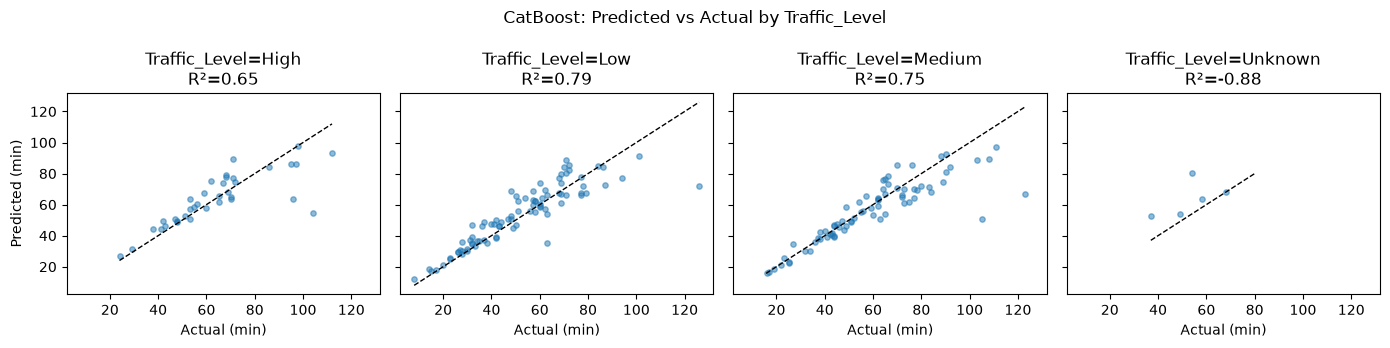

[08/17/26 10:14:10] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409006;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409007;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

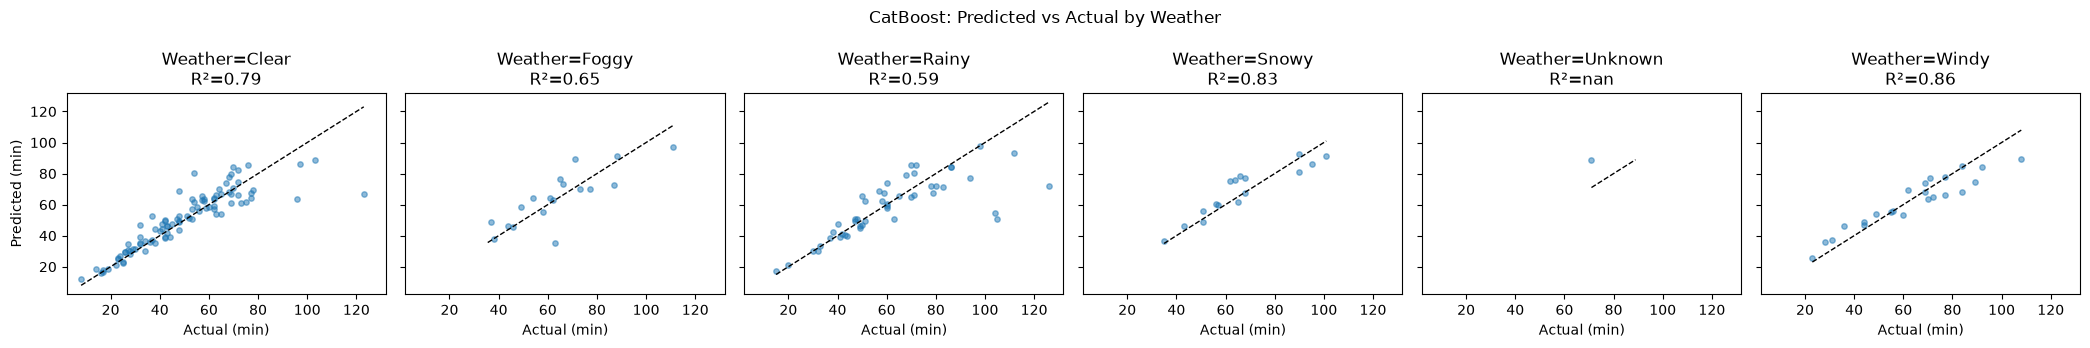

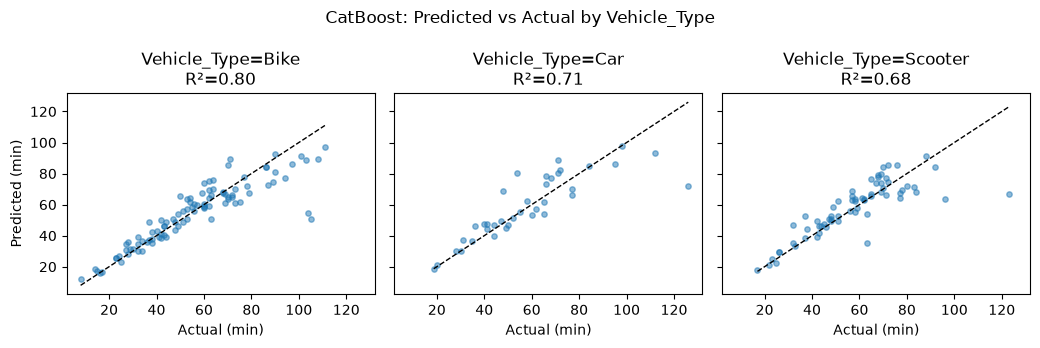

In [11]:
predictions_by_model = {}

for model_name, dataset_name in prediction_tables.items():
    predictions = catalog.load(dataset_name).reset_index(drop=True)
    predictions = pd.concat([predictions, category_values], axis=1)
    predictions_by_model[model_name] = predictions

    for category_col in CATEGORY_COLS:
        plot_predictions_by_category(model_name, predictions, category_col)

## Average R² by Section, Across All Models

For each category level (section) within Traffic_Level, Weather, and Vehicle_Type, the R² is averaged across all 5 models -- to see whether a weak fit in a given section holds consistently across model architectures, rather than being an artifact of one model.

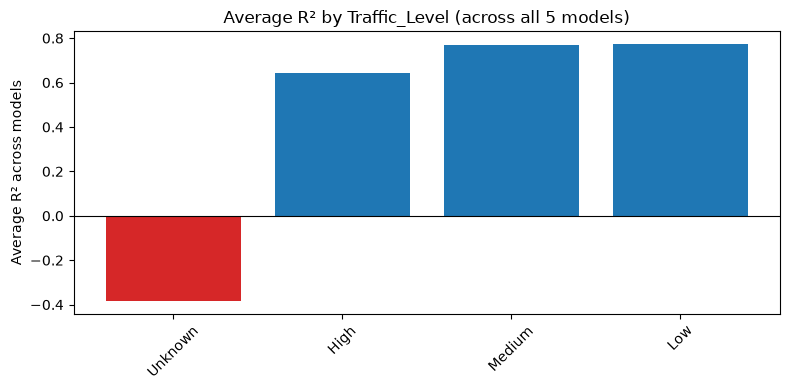

[08/17/26 10:14:11] WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409012;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409013;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

                    WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409018;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409019;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

                    WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409024;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409025;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

                    WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409030;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409031;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

                    WARNING  /opt/conda/envs/deliveryenv/lib/python3.12/site-packages/sklearn/metri ]8;id=3409036;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py\warnings.py]8;;\:]8;id=3409037;file:///opt/conda/envs/deliveryenv/lib/python3.12/warnings.py#112\112]8;;\
                             cs/_regression.py:1295: UndefinedMetricWarning: R^2 score is not                      
                             well-defined with less than two samples.                                              
                               warnings.warn(msg, UndefinedMetricWarning)                                          
                                                                                                                   

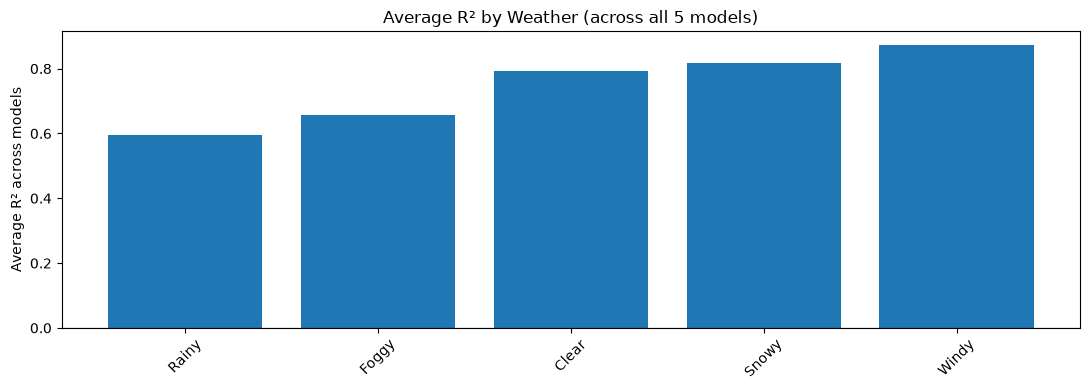

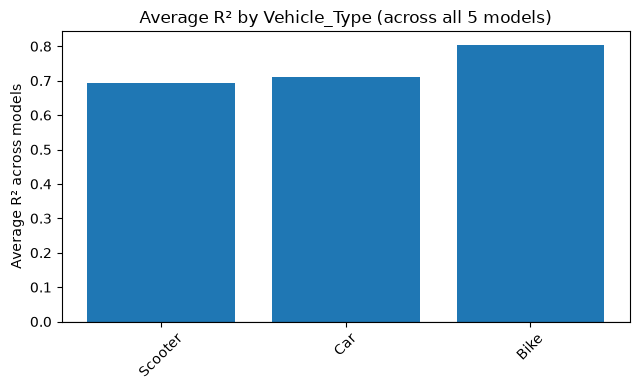

In [12]:
for category_col in CATEGORY_COLS:
    r2_rows = []
    for model_name, predictions in predictions_by_model.items():
        for level in sorted(predictions[category_col].unique()):
            subset = predictions[predictions[category_col] == level]
            r2_rows.append(
                {
                    "Model": model_name,
                    category_col: level,
                    "R2": r2_score(subset["y_true"], subset["y_pred"]),
                }
            )
    r2_table = pd.DataFrame(r2_rows)
    avg_r2 = r2_table.groupby(category_col)["R2"].mean().sort_values()

    fig, ax = plt.subplots(figsize=(1.5 * len(avg_r2) + 2, 4))
    colors = ["tab:red" if v < 0 else "tab:blue" for v in avg_r2]
    ax.bar(avg_r2.index.astype(str), avg_r2.values, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_ylabel("Average R² across models")
    ax.set_title(f"Average R² by {category_col} (across all 5 models)")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    plt.show()